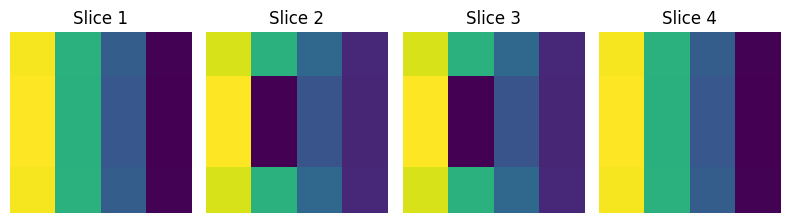

[[-5.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[1.0 ,-4.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[0.0 ,1.0 ,-4.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[0.0 ,0.0 ,1.0 ,-5.0 ,0.

C:\Users\Rafael\AppData\Local\Temp\ipykernel_201736\4099190374.py:17: RuntimeWarning: overflow encountered in cast
  residuals[row] = residual


In [1]:
%run darcy_solver.ipynb

In [2]:
import time

In [3]:
import os
os.chdir("..")
print(os.getcwd())

D:\repositories\PyFlowSolver


In [4]:
%run .\pyflowsolver\volumeManager.py
%run .\pyflowsolver\sparseArray.py
%run .\pyflowsolver\fastLaplacian.py
%run .\pyflowsolver\darcySolver.py

In [5]:
import porespy as ps

In [6]:
SIZE = 130
vol = ps.generators.blobs(shape=(SIZE, SIZE, SIZE), blobiness=0.4, porosity=0.55)

In [7]:
import numpy as np
import scipy as sc

In [8]:
lab, n_lab = sc.ndimage.label(vol)

In [9]:
print(np.unique(lab[0,:,:]))
print(np.unique(lab[-1,:,:]))
print(np.unique(lab[:,0,:]))
print(np.unique(lab[:,-1,:]))
print(np.unique(lab[:,:,0]))
print(np.unique(lab[:,:,-1]))

[0 1]
[0 1]
[0 1]
[0 1]
[0 1]
[0 1]


In [10]:
con_vol = (lab==1)*100 #porosity map ndarray unit8 0..100

In [11]:
con_vol = fast_laplacian_volume_generator(
    con_vol, 
    (1.2, 1.2, 1.2), 
    )

In [12]:
volume_manager = VolumeManager(con_vol)
solver = DarcySolver()

In [15]:
start_time = time.perf_counter()
print("Starting: ", start_time)

sparse_A, sparse_b = volume_manager.get_sparse_system_jit()
print("Get sparse syste: ", time.perf_counter() - start_time)
start_time = time.perf_counter()

solution = solver.solve_jit(sparse_A, sparse_b)
print("Solving: ", time.perf_counter() - start_time)
start_time = time.perf_counter()

raveled_solution = volume_manager.ravel_sparse_solution(solution)
print("Raveling", time.perf_counter() - start_time)

Starting:  1071361.2667079
Get sparse syste:  3.2151643000543118
Solving:  58.76928979996592
Raveling 0.9238042999058962


In [21]:
start_time = time.perf_counter()
print("Starting: ", start_time)

sparse_A, sparse_b = volume_manager.get_sparse_system_jit()
print("Get sparse syste: ", time.perf_counter() - start_time)
start_time = time.perf_counter()

solution = solver.solve_jit(sparse_A, sparse_b, parallel=True)
print("Solving: ", time.perf_counter() - start_time)
start_time = time.perf_counter()

raveled_solution = volume_manager.ravel_sparse_solution(solution)
print("Raveling", time.perf_counter() - start_time)

Starting:  1072513.3112544
Get sparse syste:  3.1844548999797553
Solving:  26.25026370002888
Raveling 0.9771145998965949


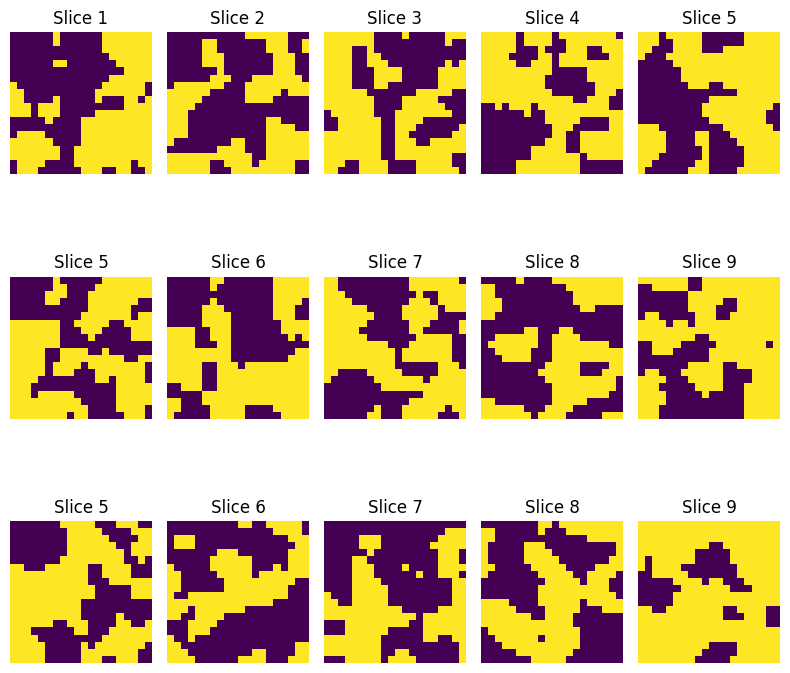

In [31]:
plt_show(vol, 4)

In [37]:
print(con_vol.min(), con_vol.max())
print(pressure_field[0, :, :].mean())
print(pressure_field[-1, :, :].mean())
print(pressure_field[:, 0, :].mean())
print(pressure_field[:, -1, :].mean())
print(pressure_field[:, :, 0].mean())
print(pressure_field[:, :, -1].mean())

0.0 20.170599
0.11339037
0.21797691
0.25111377
0.2096033
0.57495
0.0025292796


In [42]:
pressure_field = raveled_solution
x_pressure_gradient = np.zeros_like(pressure_field)
x_pressure_gradient[1:, :, :] -= x_pressure_gradient[:-1, :, :]
x_conductance = np.zeros_like(pressure_field)
x_conductance[1:, :, :] = 2/ (1/x_conductance[1:, :, :] + 1/x_conductance[:-1, :, :])
x_speed = x_pressure_gradient * x_conductance

0.0 0.0


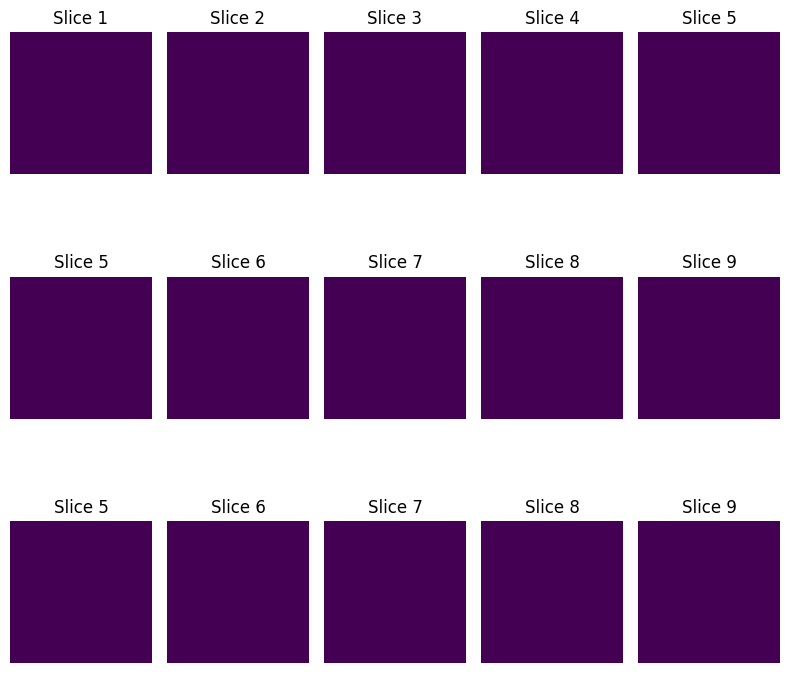

In [44]:
print(x_speed.min(), x_speed.max())
plt_show(x_speed, 4)

In [25]:
import multiprocessing

processor_n = multiprocessing.cpu_count()
threads = int(0.8 * processor_n)
print(threads)

25


In [19]:
np.array((np.inf,), dtype=np.float32).shape

(1,)

In [23]:
import psutil

In [24]:
psutil.cpu_count(logical=False)

16

In [25]:
psutil.cpu_count(logical=True)

32

In [18]:
type(4) == int

True